# Hvor mye fart kan et magnetisk objekt få i en MR-maskin?

De fleste er kjent med at det er farlig å ha et magnetisk objekt nærme en MR-maskin, enten dette er gjennom TV-serier eller nyhetssaker. Men hvor farlig er det egentlig? I dette computational essayet, skal vi forsøke å få et kvantitativt svar på dette spørsmålet. Mer spesifikt, skal vi se på hvor mye fart en kule av jern kan få, hvis den er plassert nærme en MR-maskin.

Under er all koden plassert for lettere oversikt, men den blir forklart stegvis gjennom essayet.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image

def blist(r, rlist, dlist, I=2.2e+4):
    """
    Funksjon som beregner magnetfeltet B i punktet r
    basert på en liste av strømelementposisjoner (rlist)
    og differensialelementer (dlist) med strøm I.
    Args:
        r (posisjon der B skal beregnes): array
        rlist (liste med posisjoner til strømelementene): liste av arrays
        dlist (liste med differensialelementer): liste av arrays
        I (strøm): float, standardverdi 1
    """
    N = len(dlist)
    B = 0
    mu0 = 4*np.pi*10e-7
    for idx in range(N):
        dl = dlist[idx]
        robj = rlist[idx]
        R = r-robj
        dB = mu0/(4*np.pi)*I*np.cross(dl, R)/(np.linalg.norm(R)**3)
        B = B+dB
    return B

def rpos_obj(L, R, N, wrap):
    """
    Funksjon som lager posisjonen til strømelementene
    Args:
        L (lengde av solenoide): float
        R (radius til solenoide): float
        N (antall elementer): int
    Returnerer:
        robj_list (liste med posisjoner til strømelementene): liste av arrays
        dlist (liste med differensialelementer): liste av arrays
    """
    N3 = wrap*N #Antall runder/vindinger vi ønsker
    z = np.linspace(-L/2, L/2, N3)
    robj_list = []

    #Loop for å finne posisjoner
    for i in range(N3):
        dtheta = 2*np.pi/N
        theta = dtheta*i
        rx = np.cos(theta)*R
        ry = np.sin(theta)*R
        rz = z[i]
        robj = np.array([rx, ry, rz])
        robj_list.append(robj)

    #Differensialelement
    tmpindex = len(robj_list)
    dlist = [robj_list[i+1]-robj_list[i] for i in range(tmpindex-1)] #-1 i+1

    return robj_list, dlist


def rpos_sphere():
    """
    Funksjon som lager posisjoner inni en kule
    Returnerer:
        positions (N, 3) array med posisjoner inni kula: array
        phi (longitude angles): array
        theta (latitude angles): array


    """
    #Konstanter
    R = 0.2  #Radius på kula

    # Antall punkter i hver retning
    n_lat = 50
    n_lon = 100
    n_r = 100

    #Sfæriske koordinater
    theta = np.linspace(0, np.pi, n_lat)      #Theta vinkel (fra x-akse)
    phi = np.linspace(0, 2*np.pi, n_lon)      #Phi vinkel (fra z-akse)
    r = np.linspace(0, R, n_r)                #Radiell avstand

    #Grid for broadcasting
    rg, theta_g, phi_g = np.meshgrid(r, theta, phi, indexing="ij")

    #Kartesiske koordinater
    x = rg * np.sin(theta_g) * np.cos(phi_g)
    y = rg * np.sin(theta_g) * np.sin(phi_g)
    z = rg * np.cos(theta_g)

    #Posisjonsvektor
    positions = np.stack((x, y, z), axis=-1) # shape (n_r, n_lat, n_lon, 3)
    positions = np.reshape(positions, (-1, 3)) # shape (N, 3), lettere å itterere over
    return positions, phi, theta

def plot_sphere(phi, theta, R=10, center=(0, 0, 0)):
    """
    Funksjon som plotter utsiden av en kule
    Args:
        phi (z-akse vinkel): array
        theta (x-akse vinkel): array
        R (radius): float
        center (midten av kula): array
    Returnerer:
        plot av utsiden av kula
    
    """
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')
    x0, y0, z0 = center

    theta_b, phi_b = np.meshgrid(theta, phi, indexing='ij')

    x = x0 + R * np.sin(theta_b) * np.cos(phi_b)
    y = y0 + R * np.sin(theta_b) * np.sin(phi_b)
    z = z0 + R * np.cos(theta_b)

    ax.plot_surface(x, y, z, cmap="magma", linewidth=0)
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Jernkule')
    
    plt.show()

def euler(Nt, T, r0, v0, rlist, dlist):
    """
    Funksjon som simulerer bevegelsen til en partikkel i et magnetfelt
    Args:
        Nt (antall tidssteg): int
        T (total tid): float
        r0 (startposisjon): array
        v0 (startfart): array
        rlist (liste med posisjoner til strømelementene): liste av arrays
        dlist (liste med differensialelementer): liste av arrays
    Returnerer:
        r (posisjoner til partikkelen over tid): array
        v (farten til partikkelen over tid): array
        t (tidspunkt): array
    """
    mu_r = 7000
    mu0 = 4*np.pi*1e-7
    V = 0.004
    C = V*(mu_r-1)/(mu_r*mu0)
    dt = (T/Nt)
    m = 32

    r = np.zeros((Nt+1, 3))
    v = np.zeros((Nt+1, 3))
    t = np.zeros(Nt+1)

    r[0] = r0
    v[0] = v0

    for it in range(Nt):
        rpos = r[it]
        eps = 1e-3
        epsx = np.array([eps, 0, 0])
        epsy = np.array([0, eps, 0])
        epsz = np.array([0, 0, eps])
        Bx_p = blist(rpos + epsx, rlist, dlist)
        Bx_m = blist(rpos - epsx, rlist, dlist)
        By_p = blist(rpos + epsy, rlist, dlist)
        By_m = blist(rpos - epsy, rlist, dlist)
        Bz_p = blist(rpos + epsz, rlist, dlist)
        Bz_m = blist(rpos - epsz, rlist, dlist)
        
        dB2_dx = (np.dot(Bx_p,Bx_p) - np.dot(Bx_m,Bx_m)) / (2*eps)
        dB2_dy = (np.dot(By_p,By_p) - np.dot(By_m,By_m)) / (2*eps)
        dB2_dz = (np.dot(Bz_p,Bz_p) - np.dot(Bz_m,Bz_m)) / (2*eps)


        Fvec = C*np.array([dB2_dx, dB2_dy, dB2_dz])

        a = Fvec/m
        v[it+1] = v[it] + a*dt
        r[it+1] = r[it] + v[it+1]*dt
        t[it+1] = t[it] + dt
    return r, v, t

# Modellering og bakgrunn

En MR-maskin er en maskin som bruker sterke magneter, radiobølger og datamaskiner for å nøyaktige bilder av forskjellige deler av kroppen. De fleste MR-maskiner tar enten i bruk permanente, resistive eller superledende magneter [1]. En permanent magnet MR bruker magnetisert jern for å skape et uniformt magnetisk felt. Selv om det kan være nødvendig med opptil 30 tonn med jern for slike maskiner, er de mye billigere enn superledende magneter [1]. Ulempen er at feltstyrken på magnetfeltet er lav, omtrent 0.15T-0.4T [1]. 

Resistive og superledende MR-maskiner, bruker begge spoler formet som en solenoide for å skape et uniformt felt. Den største forskjellen er materiale som spolen er laget av, derav navna. Superledende maskiner har den høyeste feltstyrken, som ligger vanligvis på 1.5T-7.0T, men kan også være høyere [1]. Det er denne typen MR-maskiner som vi kommer til å interesse oss i for denne analysen. 

# Jernkule

Jernkulen vi plasserer i nærheten av MR-maskinen har diameter 0.20m. Massen til kulen finner vi fra volumet til kulen og massetettheten til jern:

$$m=\rho*V=\rho*\frac{4}{3}\pi r^3$$
$$m=7680kg/m^3*\frac{4}{3}\pi (0.10m)^3$$
$$m=32.17\approx 32kg$$

Under er en kode som visualiserer denne kulen i et plott, samt finner posisjoner til kulen for fremtidig bruk.


In [2]:
def rpos_sphere():
    """
    Funksjon som lager posisjoner inni en kule
    Returnerer:
        positions (N, 3) array med posisjoner inni kula: array
        phi (longitude angles): array
        theta (latitude angles): array


    """
    #Konstanter
    R = 0.2  #Radius på kula

    # Antall punkter i hver retning
    n_lat = 50
    n_lon = 100
    n_r = 100

    #Sfæriske koordinater
    theta = np.linspace(0, np.pi, n_lat)      #Theta vinkel (fra x-akse)
    phi = np.linspace(0, 2*np.pi, n_lon)      #Phi vinkel (fra z-akse)
    r = np.linspace(0, R, n_r)                #Radiell avstand

    #Grid for broadcasting
    rg, theta_g, phi_g = np.meshgrid(r, theta, phi, indexing="ij")

    #Kartesiske koordinater
    x = rg * np.sin(theta_g) * np.cos(phi_g)
    y = rg * np.sin(theta_g) * np.sin(phi_g)
    z = rg * np.cos(theta_g)

    #Posisjonsvektor
    positions = np.stack((x, y, z), axis=-1) # shape (n_r, n_lat, n_lon, 3)
    positions = np.reshape(positions, (-1, 3)) # shape (N, 3), lettere å itterere over
    return positions, phi, theta

def plot_sphere(phi, theta, R=10, center=(0, 0, 0)):
    """
    Funksjon som plotter utsiden av en kule
    Args:
        phi (z-akse vinkel): array
        theta (x-akse vinkel): array
        R (radius): float
        center (midten av kula): array
    Returnerer:
        plot av utsiden av kula
    
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x0, y0, z0 = center

    theta_b, phi_b = np.meshgrid(theta, phi, indexing='ij')

    x = x0 + R * np.sin(theta_b) * np.cos(phi_b)
    y = y0 + R * np.sin(theta_b) * np.sin(phi_b)
    z = z0 + R * np.cos(theta_b)

    ax.plot_surface(x, y, z, cmap="magma", linewidth=0)
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Jernkule')
    plt.show()


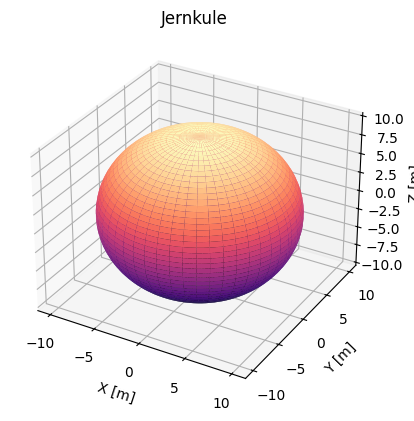

In [4]:
positions, phi, theta = rpos_sphere()
plot_sphere(phi, theta)

# Solenoide 
For å begynne modelleringen, velger vi å starte med en funksjon som finner det magnetiske feltet fra et vilkårlig strømelement.

In [ ]:
def blist(r, rlist, dlist, I=22):
    """
    Funksjon som beregner magnetfeltet B i punktet r
    basert på en liste av strømelementposisjoner (rlist)
    og differensialelementer (dlist) med strøm I.
    Args:
        r (posisjon der B skal beregnes): array
        rlist (liste med posisjoner til strømelementene): liste av arrays
        dlist (liste med differensialelementer): liste av arrays
        I (strøm): float, standardverdi 1
    """
    N = len(dlist)
    B = 0
    mu0 = 4*np.pi*10e-7
    for idx in range(N):
        dl = dlist[idx]
        robj = rlist[idx]
        R = r-robj
        dB = mu0/(4*np.pi)*I*np.cross(dl, R)/(np.linalg.norm(R)**3)
        B = B+dB
    return B

Videre er neste steg å modellere solenoiden, for å finne de relevante størrelsene som vi må sende inn i funksjonen blist. Dette er da altså posisjonselementene og differensialelemntene til solenoiden:

In [ ]:
def rpos_obj(L, R, N, wrap):
    """
    Funksjon som lager posisjonen til strømelementene
    Args:
        L (lengde av solenoide): float
        R (radius til solenoide): float
        N (antall elementer per vinding): int
    Returnerer:
        robj_list (liste med posisjoner til strømelementene): liste av arrays
        dlist (liste med differensialelementer): liste av arrays
    """
    N3 = wrap*N #Antall runder/vindinger vi ønsker
    z = np.linspace(-L/2, L/2, N3)
    robj_list = []

    #Loop for å finne posisjoner
    for i in range(N3):
        dtheta = 2*np.pi/N
        theta = dtheta*i
        rx = np.cos(theta)*R
        ry = np.sin(theta)*R
        rz = z[i]
        robj = np.array([rx, ry, rz])
        robj_list.append(robj)

    #Differensialelement
    tmpindex = len(robj_list)
    dlist = [robj_list[i+1]-robj_list[i] for i in range(tmpindex-1)] #-1 siden vi går til i+1

    return robj_list, dlist


For å finne typiske verdier for solenoider, tar vi utgangspunkt i tabell 5 fra [2] for en 1.5T MR. Fra tabellen leser vi at vi har en lengde på $l=1.55m$, og en radius på $R=0.95m/2=0.475m$. For å estimere antall vindinger, bruker vi formelen for induktansen til en solenoide:

$$L=\frac{N^2 \mu_{0} A}{l}$$
Der L er induktansen, N er antall vindinger, $\mu_{0}$ er magnetisk permabilitet i fritt rom, A er arealet til tverrsnitt, og l er lengden på solenoiden. 

$$N=\sqrt{\frac{L*l}{\mu_{0}A}}=\sqrt{72.2 \cdot \frac{1.55}{4\pi \cdot 10^{-7}} \cdot \frac{1}{\pi \cdot (0.95/2)^2}}$$
$$=11208\approx 11200$$
Der vi har satt inn L=72.2 fra tabellen.

Det betyr at vi har omtrent 5600 vindinger for denne solenoiden! Her støter vi på vårt første problem. Slik funksjonen rpos_obj er laget, så er N antall elementer per vinding. Det betyr at for N=100 kan vi forvente ca. 1 million elementer totalt i solenoiden. Det krever mye regnekraft, spesielt med tanke på at vi kommer til å loope over disse elementene mange ganger i blist, osv. 

Men det finnes en trøst. Magnefeltet for en uendelig solenoide er gitt ved:

$$B_{z}=\frac{\mu_{0}NI}{l}$$

Siden $B\propto NI$ kan vi isteden gjøre en forenkling ved å øke strømmen i solenoiden, til magnetfeltet inni maskinen blir av samme styrke som vi ville forvente med riktig antall vindinger.


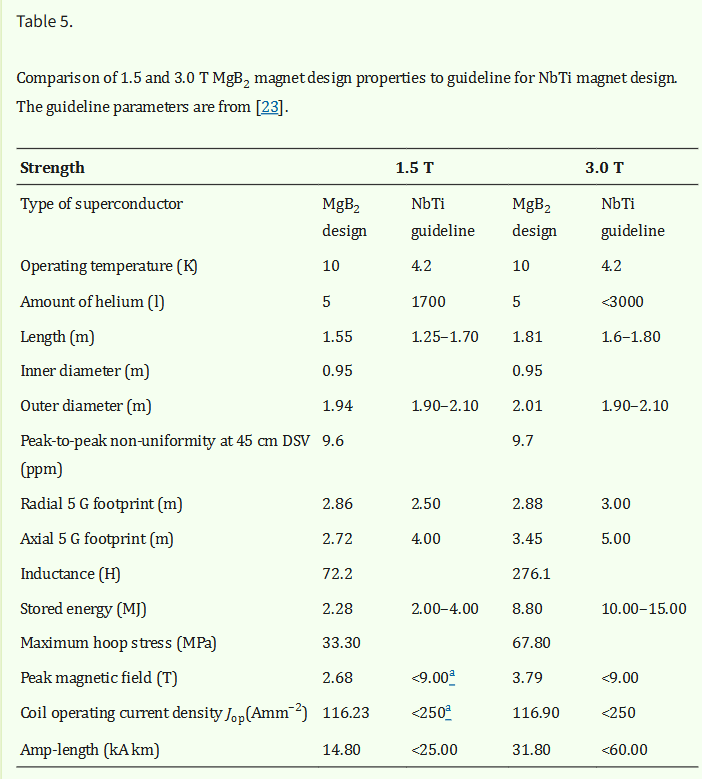

In [43]:
Image(filename='C://users//Nico//Pictures/MRITabell.png')

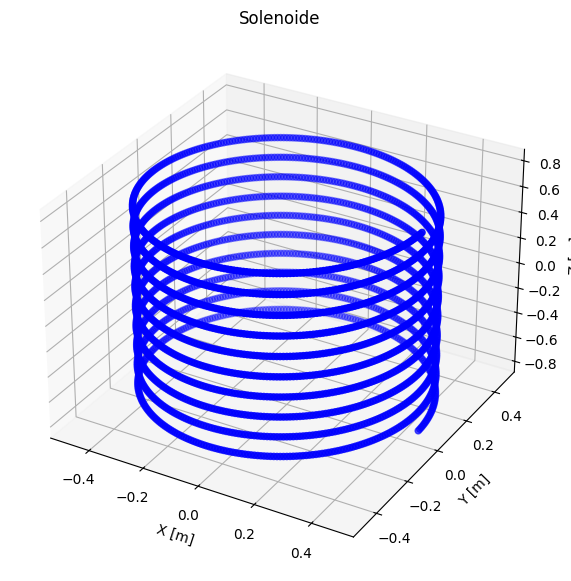

In [6]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

rlist, dlist = rpos_obj(L=1.55, R=0.475, N=300, wrap=10)
rlistarr = np.array(rlist) #Punkter fra solenoide som array

x_sol, y_sol, z_sol = rlistarr[:,0], rlistarr[:,1], rlistarr[:,2]
ax.scatter(x_sol, y_sol, z_sol, c='b') 
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.set_title('Solenoide')
plt.show()

In [ ]:
rmidt = np.array([0, 0, 0])
Bmidt = blist(rmidt, rlist, dlist, I=2.2e+4)
Bmag = np.linalg.norm(Bmidt)
print(f"{Bmag:.2f}")

1.52


Vi finner at å sette I=22000 er en god verdi for å oppnå magnetfeltet vi ønsker i MR-maskinen.

Under er et plott for å visualisere magnetfeltet til solenoiden i xz-planet.

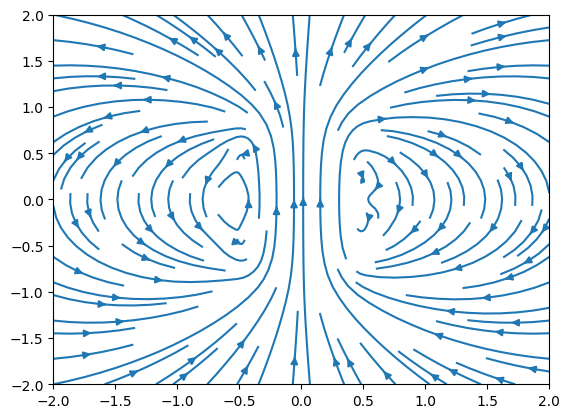

In [ ]:
x = np.linspace(-2, 2, 20)
z = np.linspace(-2, 2, 20)
rx, rz = np.meshgrid(x, z)
Bx = rx.copy()
Bz = rz.copy()
for i in range(len(rx.flat)):
    pos = np.array([rx.flat[i], 0, rz.flat[i]])
    Bx.flat[i], By, Bz.flat[i] =  blist(pos, rlist, dlist, I=2.2e+4)
plt.streamplot(x, z, Bx, Bz)

# Kraft (teori)

Før vi ser på hvordan jernkulen vår beveger seg i magnetfeltet, må vi først knytte magnetfeltet til et kraftuttrykk. For å finne dette begynner vi med uttrykket for kraftmoment på en magnetisk dipol:
$$\vec{\tau} = \vec{m} \times \vec{B}$$
Fra dette kan vi definere en potensiell energi, ved å se på arbeidet vi utfører ved å rotere dipolen en vinkel $d\theta$
$$dU = -dW = -\tau d\theta=mBsin(\theta)d\theta$$
$$U = \int -mB*sin(\theta)d\theta=-mBcos(\theta)+C$$
Det siste uttrykket kjenner vi igjen som prikkproduktet (hvis vi velger $U(\theta_{0})$ slik at C=0)
$$U(\theta)=-\vec{m} \cdot \vec{B}$$
Kraften finner vi fra:
$$\vec{F}=-\nabla U=\nabla (\vec{m} \cdot \vec{B})$$
Merk at jernkulen vår består av flere slike små magnetiske dipoler over volumet. Hvert magnetisk dipol har en magnetisering:
$$\vec{m} = \vec{M} dV$$
Slik at:
$$\vec{dF}=\nabla(\vec{M} \cdot \vec{B})dV$$
$$\vec{F}=\int \nabla(\vec{M} \cdot \vec{B})dV$$
Til å begynne med antar vi at kraften er uniform over volumet til kulen:
$$\vec{F}=V\nabla(\vec{M} \cdot \vec{B})$$
Videre tilnærmer vi jern som et linært magnetiserbart materiale, slik at magnetiseringen $\vec{M}$ er proporsjonal med H-feltet $\vec{H}$:
$$\vec{M}=\chi_{m}\vec{H}$$
$$\vec{B}=\mu\vec{H}$$
$$\vec{M}=\frac{\chi_{m}}{\mu}\vec{B}=\frac{\mu_{r}-1}{\mu_{0} \mu_{r}}\vec{B}$$

Der $\chi_{m}$ er den magnetiske susceptibiliteten, og $\mu_{r}$ er den relative magnetiske permeabiliteten. For jernkula vår antar vi at vi har en $\mu_{r}$=7000, som er verdien for jern som er blandet med litt silisium [3].

Setter vi uttrykket for $\vec{M}$ tilbake inn i $\vec{F}$ har vi:
$$\vec{F}=V\frac{\mu_{r}-1}{\mu_{0} \mu_{r}} \nabla B^2$$

# Simulering

Med dette kraftutrykket kan vi nå se hvordan jernkula beveger seg med tid. Dette gjør vi ved å bruke en Euler-Cromer integrator:

In [24]:
def eulercromer(Nt, T, v0, r0, rlist, dlist):
    """
    Funksjon som simulerer bevegelsen til en partikkel i et magnetfelt
    Args:
        Nt (antall tidssteg): int
        T (total tid): float
        r0 (startposisjon): array
        v0 (startfart): array
        rlist (liste med posisjoner til strømelementene): liste av arrays
        dlist (liste med differensialelementer): liste av arrays
    Returnerer:
        r (posisjoner til partikkelen over tid): array
        v (farten til partikkelen over tid): array
        t (tidspunkt): array
    """
    mu_r = 7000
    mu0 = 4*np.pi*1e-7
    V = 0.004
    C = V*(mu_r-1)/(mu_r*mu0)
    dt = (T/Nt)
    m = 32

    r = np.zeros((Nt+1, 3))
    v = np.zeros((Nt+1, 3))
    t = np.zeros(Nt+1)

    r[0] = r0
    v[0] = v0

    for it in range(Nt):
        rpos = r[it]
        eps = 1e-3
        epsx = np.array([eps, 0, 0])
        epsy = np.array([0, eps, 0])
        epsz = np.array([0, 0, eps])
        Bx_p = blist(rpos + epsx, rlist, dlist)
        Bx_m = blist(rpos - epsx, rlist, dlist)
        By_p = blist(rpos + epsy, rlist, dlist)
        By_m = blist(rpos - epsy, rlist, dlist)
        Bz_p = blist(rpos + epsz, rlist, dlist)
        Bz_m = blist(rpos - epsz, rlist, dlist)
        
        dB2_dx = (np.dot(Bx_p,Bx_p) - np.dot(Bx_m,Bx_m)) / (2*eps)
        dB2_dy = (np.dot(By_p,By_p) - np.dot(By_m,By_m)) / (2*eps)
        dB2_dz = (np.dot(Bz_p,Bz_p) - np.dot(Bz_m,Bz_m)) / (2*eps)


        Fvec = C*np.array([dB2_dx, dB2_dy, dB2_dz])

        a = Fvec/m
        v[it+1] = v[it] + a*dt
        r[it+1] = r[it] + v[it+1]*dt
        t[it+1] = t[it] + dt
    return r, v, t

In [25]:
r, v, t = euler(Nt=50, T=4, v0=np.array([0,0,0]), r0=np.array([0.4, -0.4, -2]), rlist=rlist, dlist=dlist)


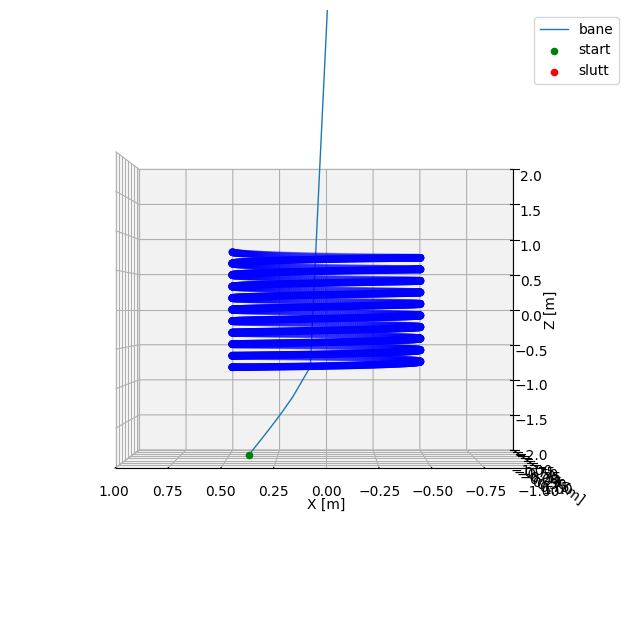

In [26]:
fig = plt.figure(figsize=(8,8))
x, y, z = r[:,0], r[:,1], r[:,2]
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, '-', lw=1, label='bane')
ax.scatter([x[0]], [y[0]], [z[0]], c='g', label='start')
ax.scatter([x[-1]], [y[-1]], [z[-1]], c='r', label='slutt')
ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]'); ax.set_zlabel('Z [m]')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-2, 2])
ax.legend()

rlistarr = np.array(rlist)
x_sol, y_sol, z_sol = rlistarr[:,0], rlistarr[:,1], rlistarr[:,2] #solenoid points
ax.scatter(x_sol, y_sol, z_sol, c='b', s=20)
ax.view_init(elev=0, azim=90) 
plt.show()

Vi observerer fra plottet at jernkula følger de linjene vi forventer med tanke på streamplottet i xz-planet. Merk også at sluttpunktet ikke er synlig, kula har flydd langt over grensene til plottet. Vi undersøker nærmere:

[-1.36704701  9.68486601 77.16120031]
30.67791752665182


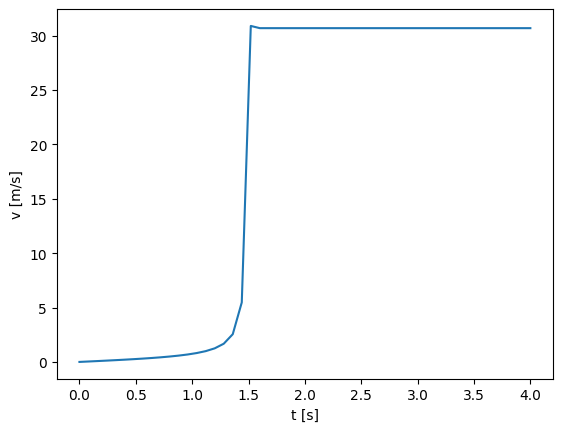

In [37]:
vmag = np.linalg.norm(v, axis=-1)
plt.xlabel("t [s]")
plt.ylabel("v [m/s]")
print(r[-1])
print(vmag[-1])
plt.plot(t, vmag)

Fra plottet ser vi at jernkula øker farten sakte i starten tidsforløpet, før den plutselig vokser til 30.7m/s i løpet av ca. 0.5s, også holder farten seg konstant. Denne økninga i fart henger trolig sammen med når jernkula kommer nærme MR-maskinen. Vi ser derimot at vi har en skarp endring i fart ved t=1.5s. Det er en oppførsel som er vanskelig å forklare siden det krever en stor endring $\frac{dF}{dt}$, og kan tyde på en numerisk feil eller feil i kode. Vi undersøker nærmere ved å plotte farten mot posisjonen i z-retning:

Text(0, 0.5, 'v [m/s]')

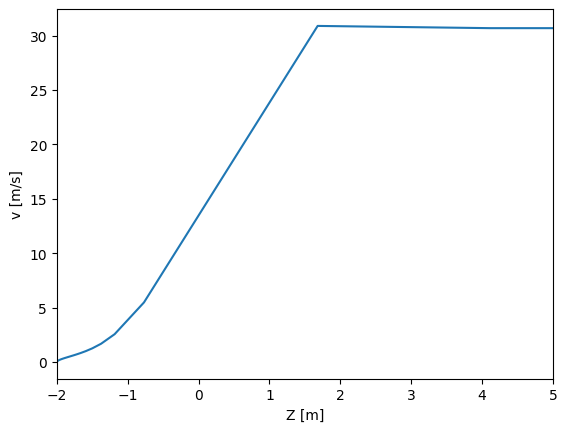

In [44]:
plt.plot(z, vmag)
plt.xlim(-2, 5)
plt.xlabel("Z [m]")
plt.ylabel("v [m/s]")

Her kan vi se at farten øker linært i et området omtrent mellom $z\in[-1, 1.90]$. En lineær økning i fart er forventet, med tanke på at feltet er tilnærmet uniformt innenfor MR-maskinen. Derimot, så fortsetter farten å øke lineært selv etter jernkula er utenfor MR-maskinen $z\in[-0.775, 0.775]$. Deakselerasjonen oppstår også utenfor MR-maskinen, ved $z=1.90$. Det er ikke forventet opppførsel. Siden feltet utenfor en solenoide burde raskt gå mot null, ville man forventet denne deakselerasjon rundt $z=0.775$, altså nærme enden av solenoiden. Dette kan tyde på numerisk feil, for eksempel med geometrien til solenoiden. 

# Konklusjon

Vi modellerte en MR-maskin som en endelig solenoide. Vi fant også magnetfeltet fra denne solenoiden. Ved å anta at jernkula er laget av et linært magnetiserbart materiale, og at B-feltet er uniformt over kula, så fant vi kraften som MR-maskin utgjør på kula. Vi så på banen til jernkula, og fant at farten økte til 30.6m/s over en periode på 0.5s. Denne perioden samsvarte omtrent med når jernkula begynte var i nærheten/innenfor MR-maskinen. Derimot observerte vi en deakselerasjon rundt $z=1.90$, som ikke samsvarte med den forventede posisjonen til deakselerasjonen, $z=0.775$, altså rundt enden av solenoiden.

# Referanser

[1] Ballinger J, Kogan J, Bell D, et al. Magnets (types). Reference article, Radiopaedia.org (Accessed on 12 Nov 2025) https://doi.org/10.53347/rID-22573

[2] Baig T, Al Amin A, Deissler RJ, Sabri L, Poole C, Brown RW, Tomsic M, Doll D, Rindfleisch M, Peng X, Mendris R, Akkus O, Sumption M, Martens M. Conceptual designs of conduction cooled MgB2 magnets for 1.5 and 3.0T full body MRI systems. Supercond Sci Technol. 2017 Apr;30(4):043002. doi: 10.1088/1361-6668/aa609b. Epub 2017 Mar 9. PMID: 29170604; PMCID: PMC5695883.

[3] Sørensen, A. M. (2025). Elementary Electromagnetism Using Python. Oslo: Springer Nature.

